# MovieLens 1M Multi-Armed Bandit

This notebook applies classical Multi-Armed Bandit algorithms to the
MovieLens 1M movie-rating dataset.

## Algorithms implemented

1. Random Baseline
2. Epsilon-Greedy
3. Decaying Epsilon-Greedy
4. Upper Confidence Bound (UCB)
5. Thompson Sampling

## Evaluation metrics

- Total Reward
- Average Reward
- Cumulative Reward
- Cumulative Regret
- Movie Selection Frequency
- Number of Experiments

## Dataset

MovieLens 1M contains approximately 1 million movie ratings from users.

The original dataset contains:

- users.dat
- movies.dat
- ratings.dat

The main file used in this notebook is:

ratings.dat

with the following columns:

    UserID::MovieID::Rating::Timestamp

## Important note

MovieLens is an offline historical dataset.

Therefore, this notebook converts the historical movie ratings into a
simulated reward environment.

For this experiment:

    Rating >= 4  -> Reward = 1
    Rating < 4   -> Reward = 0

For each movie, we estimate its historical positive-rating probability:

    P(reward = 1 | movie)

The bandit algorithms then interact with this simulated environment.

# Install/Import Libraries

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


# Check Uploaded Dataset

In [2]:
DATASET_PATH = "/content/ml-1m.zip"

if os.path.exists(DATASET_PATH):
    print("Dataset found!")
    print(f"Path: {DATASET_PATH}")
    print(f"Size: {os.path.getsize(DATASET_PATH) / (1024**2):.2f} MB")
else:
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_PATH}"
    )

Dataset found!
Path: /content/ml-1m.zip
Size: 5.64 MB


# Extract Dataset

In [3]:
EXTRACT_PATH = "/content/ml-1m"

if not os.path.exists(EXTRACT_PATH):
    with zipfile.ZipFile(DATASET_PATH, "r") as zip_ref:
        zip_ref.extractall("/content")

print("Extraction completed.")
print("Files:")
print(os.listdir(EXTRACT_PATH))

Extraction completed.
Files:
['ratings.dat', 'users.dat', 'movies.dat', 'README']


# Check Files

In [4]:
for file_name in os.listdir(EXTRACT_PATH):
    file_path = os.path.join(EXTRACT_PATH, file_name)

    if os.path.isfile(file_path):
        size_mb = os.path.getsize(file_path) / (1024**2)
        print(f"{file_name:15s} : {size_mb:.2f} MB")

ratings.dat     : 23.45 MB
users.dat       : 0.13 MB
movies.dat      : 0.16 MB
README          : 0.01 MB


# Load Ratings

In [5]:
ratings_path = os.path.join(
    EXTRACT_PATH,
    "ratings.dat"
)

ratings = pd.read_csv(
    ratings_path,
    sep="::",
    engine="python",
    names=[
        "user_id",
        "movie_id",
        "rating",
        "timestamp"
    ]
)

print("Ratings loaded successfully.")
print("Shape:", ratings.shape)

ratings.head()

Ratings loaded successfully.
Shape: (1000209, 4)


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


# Load Movies

In [6]:
movies_path = os.path.join(
    EXTRACT_PATH,
    "movies.dat"
)

movies = pd.read_csv(
    movies_path,
    sep="::",
    engine="python",
    names=[
        "movie_id",
        "title",
        "genres"
    ],
    encoding="latin-1"
)

print("Movies loaded successfully.")
print("Shape:", movies.shape)

movies.head()

Movies loaded successfully.
Shape: (3883, 3)


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


# Load Users

In [7]:
users_path = os.path.join(
    EXTRACT_PATH,
    "users.dat"
)

users = pd.read_csv(
    users_path,
    sep="::",
    engine="python",
    names=[
        "user_id",
        "gender",
        "age",
        "occupation",
        "zip_code"
    ],
    encoding="latin-1"
)

print("Users loaded successfully.")
print("Shape:", users.shape)

users.head()

Users loaded successfully.
Shape: (6040, 5)


,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


# Dataset Information

In [8]:
print("Number of ratings:", len(ratings))
print("Number of users:", ratings["user_id"].nunique())
print("Number of movies:", ratings["movie_id"].nunique())

print("\nRating range:")
print(
    ratings["rating"].min(),
    "to",
    ratings["rating"].max()
)

print("\nMissing values:")
print(ratings.isnull().sum())

Number of ratings: 1000209
Number of users: 6040
Number of movies: 3706

Rating range:
1 to 5

Missing values:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64


# Rating Distribution

rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


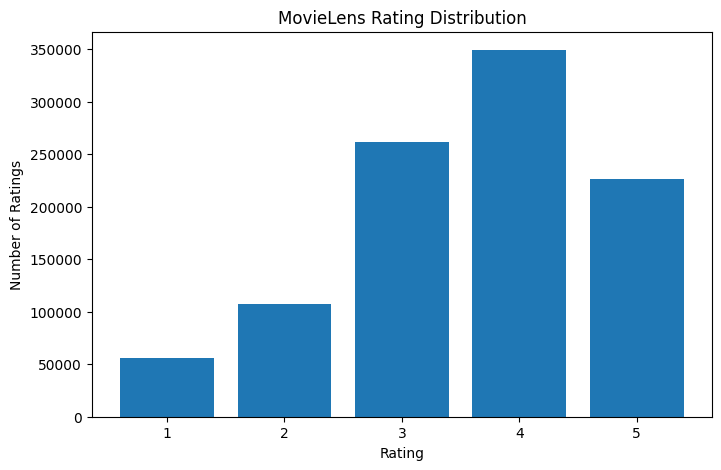

In [9]:
rating_counts = ratings["rating"].value_counts().sort_index()

print(rating_counts)

plt.figure(figsize=(8, 5))

plt.bar(
    rating_counts.index,
    rating_counts.values
)

plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("MovieLens Rating Distribution")

plt.xticks(
    [1, 2, 3, 4, 5]
)

plt.show()

# Rating Statistics

In [10]:
ratings["rating"].describe()

,rating
count,1.000209e+06
mean,3.581564e+00
std,1.117102e+00
min,1.000000e+00
25%,3.000000e+00
50%,4.000000e+00
75%,4.000000e+00
max,5.000000e+00


# Convert Ratings to Rewards

In [11]:
ratings["reward"] = (
    ratings["rating"] >= 4
).astype(int)

ratings.head()

,user_id,movie_id,rating,timestamp,reward
0,1,1193,5,978300760,1
1,1,661,3,978302109,0
2,1,914,3,978301968,0
3,1,3408,4,978300275,1
4,1,2355,5,978824291,1


# Check Reward Distribution

In [12]:
reward_counts = ratings["reward"].value_counts()

print("Reward distribution:")
print(reward_counts)

print("\nOverall positive reward rate:")
print(ratings["reward"].mean())

Reward distribution:
reward
1    575281
0    424928
Name: count, dtype: int64

Overall positive reward rate:
0.5751607913945985


# Movie-Level Statistics

In [13]:
movie_stats = (
    ratings
    .groupby("movie_id")
    .agg(
        total_ratings=("rating", "count"),
        average_rating=("rating", "mean"),
        positive_ratings=("reward", "sum"),
        positive_rate=("reward", "mean")
    )
    .reset_index()
)

movie_stats.head()

,movie_id,total_ratings,average_rating,positive_ratings,positive_rate
0,1,2077,4.146846,1655,0.796822
1,2,701,3.201141,285,0.406562
2,3,478,3.016736,148,0.309623
3,4,170,2.729412,37,0.217647
4,5,296,3.006757,96,0.324324


# Merge Movie Names

In [14]:
movie_stats = movie_stats.merge(
    movies[
        ["movie_id", "title", "genres"]
    ],
    on="movie_id",
    how="left"
)

movie_stats.head()

,movie_id,total_ratings,average_rating,positive_ratings,positive_rate,title,genres
0,1,2077,4.146846,1655,0.796822,Toy Story (1995),Animation|Children's|Comedy
1,2,701,3.201141,285,0.406562,Jumanji (1995),Adventure|Children's|Fantasy
2,3,478,3.016736,148,0.309623,Grumpier Old Men (1995),Comedy|Romance
3,4,170,2.729412,37,0.217647,Waiting to Exhale (1995),Comedy|Drama
4,5,296,3.006757,96,0.324324,Father of the Bride Part II (1995),Comedy


# Most Popular Movies

In [15]:
popular_movies = (
    movie_stats
    .sort_values(
        "total_ratings",
        ascending=False
    )
    .head(20)
)

popular_movies[
    [
        "movie_id",
        "title",
        "total_ratings",
        "average_rating",
        "positive_rate"
    ]
]

,movie_id,title,total_ratings,average_rating,positive_rate
2651,2858,American Beauty (1999),3428,4.317386,0.832264
253,260,Star Wars: Episode IV - A New Hope (1977),2991,4.453694,0.876630
1106,1196,Star Wars: Episode V - The Empire Strikes Back...,2990,4.292977,0.839465
1120,1210,Star Wars: Episode VI - Return of the Jedi (1983),2883,4.022893,0.737773
466,480,Jurassic Park (1993),2672,3.763847,0.647455
1848,2028,Saving Private Ryan (1998),2653,4.337354,0.851866
575,589,Terminator 2: Judgment Day (1991),2649,4.058513,0.771612
2374,2571,"Matrix, The (1999)",2590,4.315830,0.838224
1178,1270,Back to the Future (1985),2583,3.990321,0.739450
579,593,"Silence of the Lambs, The (1991)",2578,4.351823,0.873545


# Highest Positive-Rate Movies

In [16]:
reliable_movies = movie_stats[
    movie_stats["total_ratings"] >= 100
].copy()

highest_rated = (
    reliable_movies
    .sort_values(
        "positive_rate",
        ascending=False
    )
    .head(20)
)

highest_rated[
    [
        "movie_id",
        "title",
        "total_ratings",
        "average_rating",
        "positive_rate"
    ]
]

,movie_id,title,total_ratings,average_rating,positive_rate
708,745,"Close Shave, A (1995)",657,4.520548,0.931507
1066,1148,"Wrong Trousers, The (1993)",882,4.507937,0.928571
309,318,"Shawshank Redemption, The (1994)",2227,4.554558,0.918725
1839,2019,Seven Samurai (The Magnificent Seven) (Shichin...,628,4.560510,0.914013
843,904,Rear Window (1954),1050,4.476190,0.913333
2816,3030,Yojimbo (1961),215,4.404651,0.902326
49,50,"Usual Suspects, The (1995)",1783,4.517106,0.901851
1108,1198,Raiders of the Lost Ark (1981),2514,4.477725,0.898966
513,527,Schindler's List (1993),2304,4.510417,0.898872
689,720,Wallace & Gromit: The Best of Aardman Animatio...,438,4.426941,0.897260


# Visualize Movie Reward Probabilities

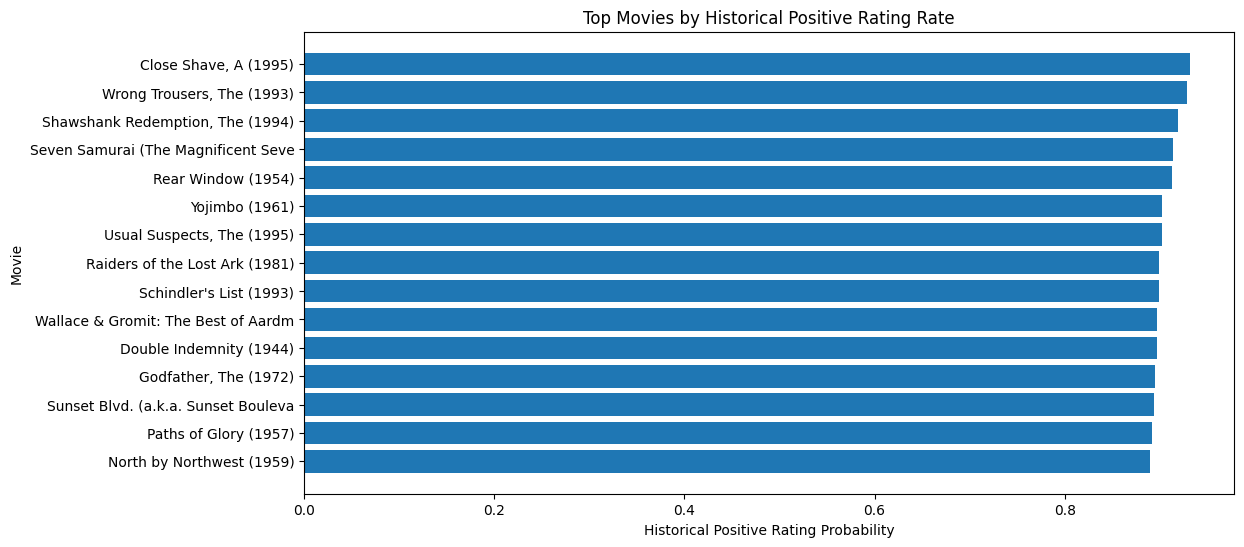

In [17]:
top_movies = (
    reliable_movies
    .sort_values(
        "positive_rate",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_movies["title"].str[:35],
    top_movies["positive_rate"]
)

plt.xlabel("Historical Positive Rating Probability")
plt.ylabel("Movie")
plt.title("Top Movies by Historical Positive Rating Rate")

plt.gca().invert_yaxis()

plt.show()

# Select Arms

In [18]:
N_ARMS = 100

arm_movies = (
    movie_stats
    .sort_values(
        "total_ratings",
        ascending=False
    )
    .head(N_ARMS)
    .copy()
    .reset_index(drop=True)
)

print("Number of arms:", len(arm_movies))

arm_movies[
    [
        "movie_id",
        "title",
        "total_ratings",
        "average_rating",
        "positive_rate"
    ]
].head(20)

Number of arms: 100


,movie_id,title,total_ratings,average_rating,positive_rate
0,2858,American Beauty (1999),3428,4.317386,0.832264
1,260,Star Wars: Episode IV - A New Hope (1977),2991,4.453694,0.876630
2,1196,Star Wars: Episode V - The Empire Strikes Back...,2990,4.292977,0.839465
3,1210,Star Wars: Episode VI - Return of the Jedi (1983),2883,4.022893,0.737773
4,480,Jurassic Park (1993),2672,3.763847,0.647455
5,2028,Saving Private Ryan (1998),2653,4.337354,0.851866
6,589,Terminator 2: Judgment Day (1991),2649,4.058513,0.771612
7,2571,"Matrix, The (1999)",2590,4.315830,0.838224
8,1270,Back to the Future (1985),2583,3.990321,0.739450
9,593,"Silence of the Lambs, The (1991)",2578,4.351823,0.873545


# Create Arm Mapping

In [19]:
movie_to_arm = {
    movie_id: arm
    for arm, movie_id
    in enumerate(arm_movies["movie_id"])
}

arm_to_movie = {
    arm: movie_id
    for arm, movie_id
    in enumerate(arm_movies["movie_id"])
}

print("Example mapping:")

for arm in range(5):
    movie_id = arm_to_movie[arm]

    title = arm_movies.iloc[arm]["title"]

    print(
        f"Arm {arm} -> "
        f"Movie ID {movie_id} -> "
        f"{title}"
    )

Example mapping:
Arm 0 -> Movie ID 2858 -> American Beauty (1999)
Arm 1 -> Movie ID 260 -> Star Wars: Episode IV - A New Hope (1977)
Arm 2 -> Movie ID 1196 -> Star Wars: Episode V - The Empire Strikes Back (1980)
Arm 3 -> Movie ID 1210 -> Star Wars: Episode VI - Return of the Jedi (1983)
Arm 4 -> Movie ID 480 -> Jurassic Park (1993)


# True Reward Probabilities

In [20]:
true_probabilities = (
    arm_movies["positive_rate"]
    .values
)

print("Number of arms:", len(true_probabilities))

print("\nFirst 10 probabilities:")

for i in range(10):
    print(
        f"Arm {i}: "
        f"{true_probabilities[i]:.4f}"
    )

Number of arms: 100

First 10 probabilities:
Arm 0: 0.8323
Arm 1: 0.8766
Arm 2: 0.8395
Arm 3: 0.7378
Arm 4: 0.6475
Arm 5: 0.8519
Arm 6: 0.7716
Arm 7: 0.8382
Arm 8: 0.7395
Arm 9: 0.8735


# Find Optimal Arm

In [21]:
optimal_arm = np.argmax(
    true_probabilities
)

optimal_probability = (
    true_probabilities[optimal_arm]
)

optimal_movie = arm_movies.iloc[
    optimal_arm
]["title"]

print("Optimal arm:", optimal_arm)
print("Optimal movie:", optimal_movie)
print(
    "Optimal reward probability:",
    optimal_probability
)

Optimal arm: 23
Optimal movie: Shawshank Redemption, The (1994)
Optimal reward probability: 0.918724741805119


# Plot Arm Probabilities

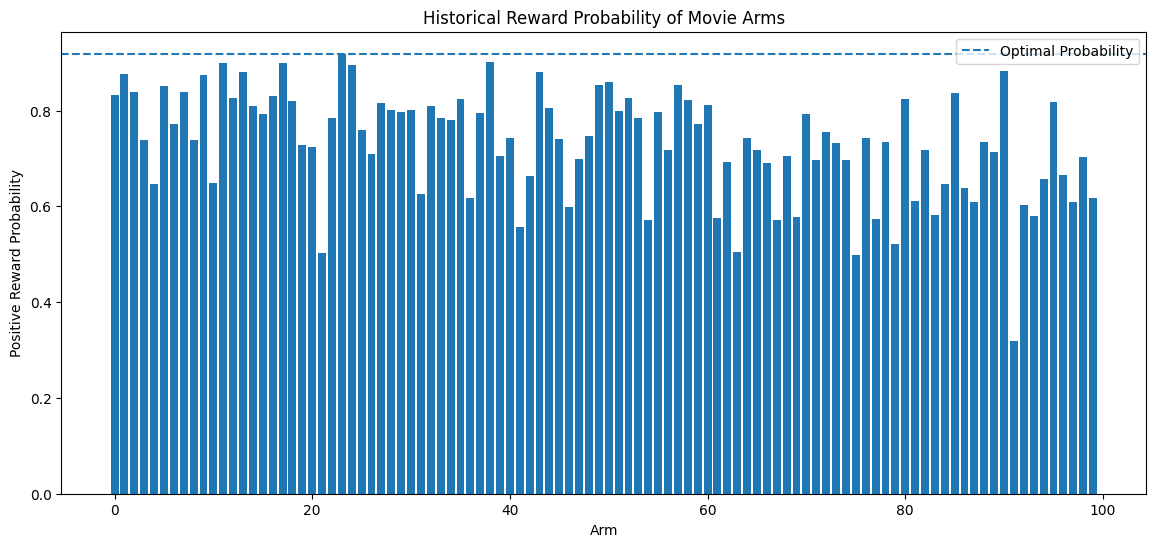

In [22]:
plt.figure(figsize=(14, 6))

plt.bar(
    range(N_ARMS),
    true_probabilities
)

plt.axhline(
    optimal_probability,
    linestyle="--",
    label="Optimal Probability"
)

plt.xlabel("Arm")
plt.ylabel("Positive Reward Probability")
plt.title(
    "Historical Reward Probability of Movie Arms"
)

plt.legend()

plt.show()

# Create Bandit Environment

In [23]:
class MovieBanditEnvironment:
    """
    Simulated MovieLens bandit environment.

    Each movie is an arm.

    A reward is sampled from a Bernoulli distribution
    using the historical positive-rating probability
    of that movie.
    """

    def __init__(self, probabilities):

        self.probabilities = np.array(
            probabilities
        )

        self.n_arms = len(
            probabilities
        )

        self.best_arm = np.argmax(
            self.probabilities
        )

        self.best_probability = np.max(
            self.probabilities
        )

    def pull(self, arm):

        probability = self.probabilities[
            arm
        ]

        reward = np.random.binomial(
            n=1,
            p=probability
        )

        return reward

# Initialize Environment

In [24]:
environment = MovieBanditEnvironment(
    true_probabilities
)

print("Number of arms:", environment.n_arms)
print("Best arm:", environment.best_arm)
print(
    "Best reward probability:",
    environment.best_probability
)

Number of arms: 100
Best arm: 23
Best reward probability: 0.918724741805119


# Test Environment

In [25]:
for arm in range(5):

    rewards = [
        environment.pull(arm)
        for _ in range(1000)
    ]

    print(
        f"Arm {arm}: "
        f"Average simulated reward = "
        f"{np.mean(rewards):.4f}"
    )

Arm 0: Average simulated reward = 0.8350
Arm 1: Average simulated reward = 0.8820
Arm 2: Average simulated reward = 0.8360
Arm 3: Average simulated reward = 0.7500
Arm 4: Average simulated reward = 0.6570


# Random Baseline

In [26]:
class RandomBandit:

    def __init__(self, n_arms):
        self.n_arms = n_arms

    def select_arm(self):
        return np.random.randint(
            self.n_arms
        )

    def update(self, arm, reward):
        pass

# Epsilon-Greedy

In [27]:
class EpsilonGreedy:

    def __init__(
        self,
        n_arms,
        epsilon=0.1
    ):

        self.n_arms = n_arms
        self.epsilon = epsilon

        self.q_values = np.zeros(
            n_arms
        )

        self.counts = np.zeros(
            n_arms
        )

    def select_arm(self):

        # Exploration
        if np.random.random() < self.epsilon:

            return np.random.randint(
                self.n_arms
            )

        # Exploitation
        return np.argmax(
            self.q_values
        )

    def update(
        self,
        arm,
        reward
    ):

        self.counts[arm] += 1

        self.q_values[arm] += (
            reward -
            self.q_values[arm]
        ) / self.counts[arm]

# Decaying Epsilon-Greedy

In [28]:
class DecayingEpsilonGreedy:

    def __init__(
        self,
        n_arms,
        initial_epsilon=1.0,
        min_epsilon=0.01,
        decay=0.999
    ):

        self.n_arms = n_arms

        self.initial_epsilon = (
            initial_epsilon
        )

        self.min_epsilon = (
            min_epsilon
        )

        self.decay = decay

        self.epsilon = (
            initial_epsilon
        )

        self.q_values = np.zeros(
            n_arms
        )

        self.counts = np.zeros(
            n_arms
        )

    def select_arm(self):

        if np.random.random() < self.epsilon:

            return np.random.randint(
                self.n_arms
            )

        return np.argmax(
            self.q_values
        )

    def update(
        self,
        arm,
        reward
    ):

        self.counts[arm] += 1

        self.q_values[arm] += (
            reward -
            self.q_values[arm]
        ) / self.counts[arm]

        self.epsilon = max(
            self.min_epsilon,
            self.epsilon * self.decay
        )

# UCB

In [29]:
class UCB:

    def __init__(
        self,
        n_arms,
        c=2.0
    ):

        self.n_arms = n_arms
        self.c = c

        self.q_values = np.zeros(
            n_arms
        )

        self.counts = np.zeros(
            n_arms
        )

        self.total_steps = 0

    def select_arm(self):

        # Select every arm at least once
        for arm in range(
            self.n_arms
        ):

            if self.counts[arm] == 0:
                return arm

        self.total_steps += 1

        exploration_bonus = (
            self.c *
            np.sqrt(
                np.log(
                    self.total_steps
                )
                /
                self.counts
            )
        )

        ucb_values = (
            self.q_values
            +
            exploration_bonus
        )

        return np.argmax(
            ucb_values
        )

    def update(
        self,
        arm,
        reward
    ):

        self.counts[arm] += 1

        self.q_values[arm] += (
            reward -
            self.q_values[arm]
        ) / self.counts[arm]

# Thompson Sampling

In [30]:
class ThompsonSampling:

    def __init__(
        self,
        n_arms
    ):

        self.n_arms = n_arms

        # Beta(1, 1) prior
        self.alpha = np.ones(
            n_arms
        )

        self.beta = np.ones(
            n_arms
        )

    def select_arm(self):

        samples = np.random.beta(
            self.alpha,
            self.beta
        )

        return np.argmax(
            samples
        )

    def update(
        self,
        arm,
        reward
    ):

        if reward == 1:

            self.alpha[arm] += 1

        else:

            self.beta[arm] += 1

    def estimated_values(self):

        return (
            self.alpha /
            (
                self.alpha +
                self.beta
            )
        )

# Experiment Function

In [31]:
def run_experiment(
    bandit,
    environment,
    n_steps=10000
):

    rewards = []
    selected_arms = []

    for step in range(n_steps):

        arm = bandit.select_arm()

        reward = environment.pull(
            arm
        )

        bandit.update(
            arm,
            reward
        )

        rewards.append(reward)
        selected_arms.append(arm)

    return (
        np.array(rewards),
        np.array(selected_arms)
    )

# Set Experiment Parameters

In [32]:
N_STEPS = 10_000

print("Number of arms:", N_ARMS)
print("Number of steps:", N_STEPS)

Number of arms: 100
Number of steps: 10000


# Run Random Baseline

In [33]:
random_bandit = RandomBandit(
    n_arms=N_ARMS
)

random_rewards, random_arms = (
    run_experiment(
        random_bandit,
        environment,
        N_STEPS
    )
)

print(
    "Total reward:",
    random_rewards.sum()
)

print(
    "Average reward:",
    random_rewards.mean()
)

Total reward: 7326
Average reward: 0.7326


# Run Epsilon-Greedy

In [34]:
epsilon_bandit = EpsilonGreedy(
    n_arms=N_ARMS,
    epsilon=0.1
)

epsilon_rewards, epsilon_arms = (
    run_experiment(
        epsilon_bandit,
        environment,
        N_STEPS
    )
)

print(
    "Total reward:",
    epsilon_rewards.sum()
)

print(
    "Average reward:",
    epsilon_rewards.mean()
)

Total reward: 8795
Average reward: 0.8795


# Run Decaying Epsilon-Greedy

In [35]:
decay_bandit = DecayingEpsilonGreedy(
    n_arms=N_ARMS,
    initial_epsilon=1.0,
    min_epsilon=0.01,
    decay=0.999
)

decay_rewards, decay_arms = (
    run_experiment(
        decay_bandit,
        environment,
        N_STEPS
    )
)

print(
    "Total reward:",
    decay_rewards.sum()
)

print(
    "Average reward:",
    decay_rewards.mean()
)

print(
    "Final epsilon:",
    decay_bandit.epsilon
)

Total reward: 8796
Average reward: 0.8796
Final epsilon: 0.01


# Run UCB

In [36]:
ucb_bandit = UCB(
    n_arms=N_ARMS,
    c=2.0
)

ucb_rewards, ucb_arms = (
    run_experiment(
        ucb_bandit,
        environment,
        N_STEPS
    )
)

print(
    "Total reward:",
    ucb_rewards.sum()
)

print(
    "Average reward:",
    ucb_rewards.mean()
)

Total reward: 7627
Average reward: 0.7627


# Run Thompson Sampling

In [37]:
thompson_bandit = ThompsonSampling(
    n_arms=N_ARMS
)

thompson_rewards, thompson_arms = (
    run_experiment(
        thompson_bandit,
        environment,
        N_STEPS
    )
)

print(
    "Total reward:",
    thompson_rewards.sum()
)

print(
    "Average reward:",
    thompson_rewards.mean()
)

Total reward: 8644
Average reward: 0.8644


# Store Results

In [38]:
results = {

    "Random": (
        random_rewards,
        random_arms
    ),

    "Epsilon-Greedy": (
        epsilon_rewards,
        epsilon_arms
    ),

    "Decaying Epsilon-Greedy": (
        decay_rewards,
        decay_arms
    ),

    "UCB": (
        ucb_rewards,
        ucb_arms
    ),

    "Thompson Sampling": (
        thompson_rewards,
        thompson_arms
    )
}

print(
    "Algorithms:",
    list(results.keys())
)

Algorithms: ['Random', 'Epsilon-Greedy', 'Decaying Epsilon-Greedy', 'UCB', 'Thompson Sampling']


# Calculate Cumulative Rewards

In [39]:
cumulative_rewards = {}

for name, (
    rewards,
    arms
) in results.items():

    cumulative_rewards[name] = (
        np.cumsum(rewards)
    )

# Plot Cumulative Reward

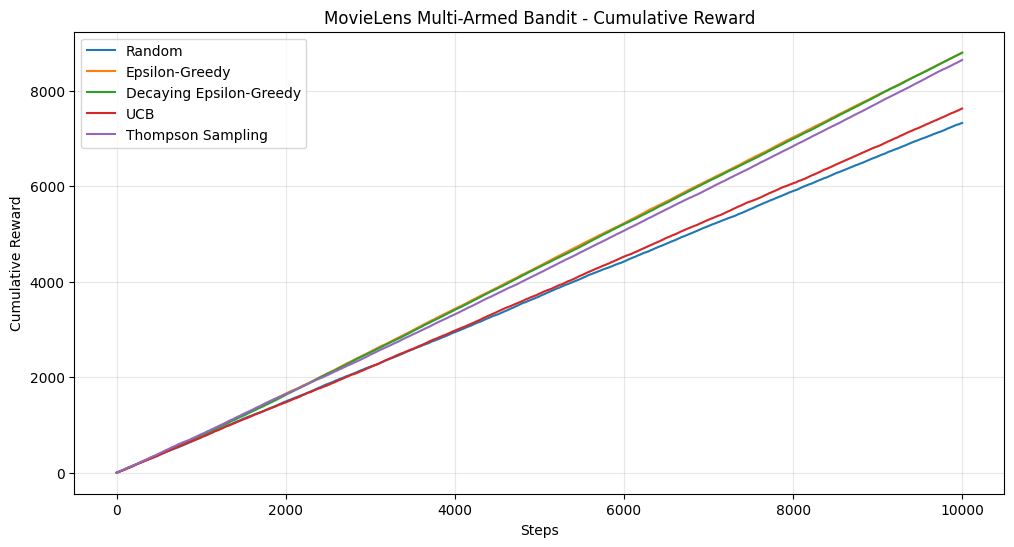

In [40]:
plt.figure(figsize=(12, 6))

for name, values in cumulative_rewards.items():

    plt.plot(
        values,
        label=name
    )

plt.xlabel("Steps")
plt.ylabel("Cumulative Reward")
plt.title(
    "MovieLens Multi-Armed Bandit - Cumulative Reward"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Calculate Average Reward

In [41]:
average_reward_results = {}

for name, (
    rewards,
    arms
) in results.items():

    average_reward_results[name] = (
        rewards.mean()
    )

average_reward_results

{'Random': np.float64(0.7326),
 'Epsilon-Greedy': np.float64(0.8795),
 'Decaying Epsilon-Greedy': np.float64(0.8796),
 'UCB': np.float64(0.7627),
 'Thompson Sampling': np.float64(0.8644)}

# Average Reward DataFrame

In [42]:
average_reward_df = pd.DataFrame({
    "Algorithm":
        list(
            average_reward_results.keys()
        ),

    "Average Reward":
        list(
            average_reward_results.values()
        )
})

average_reward_df = (
    average_reward_df
    .sort_values(
        "Average Reward",
        ascending=False
    )
    .reset_index(drop=True)
)

average_reward_df

,Algorithm,Average Reward
0,Decaying Epsilon-Greedy,0.8796
1,Epsilon-Greedy,0.8795
2,Thompson Sampling,0.8644
3,UCB,0.7627
4,Random,0.7326


# Calculate Cumulative Regret

In [43]:
regret_results = {}

for name, (
    rewards,
    arms
) in results.items():

    selected_probabilities = (
        true_probabilities[arms]
    )

    instant_regret = (
        environment.best_probability
        -
        selected_probabilities
    )

    cumulative_regret = (
        np.cumsum(
            instant_regret
        )
    )

    regret_results[name] = (
        cumulative_regret
    )

# Plot Cumulative Regret

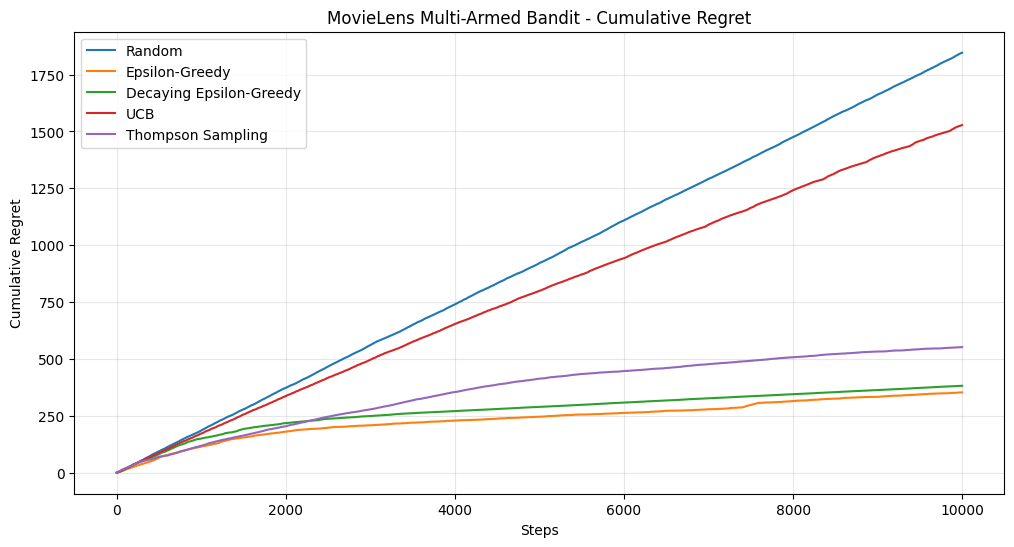

In [44]:
plt.figure(figsize=(12, 6))

for name, regret in regret_results.items():

    plt.plot(
        regret,
        label=name
    )

plt.xlabel("Steps")
plt.ylabel("Cumulative Regret")

plt.title(
    "MovieLens Multi-Armed Bandit - Cumulative Regret"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Final Regret Comparison

In [45]:
final_regret = {}

for name, regret in regret_results.items():

    final_regret[name] = regret[-1]

regret_df = pd.DataFrame({
    "Algorithm":
        list(final_regret.keys()),

    "Final Cumulative Regret":
        list(final_regret.values())
})

regret_df.sort_values(
    "Final Cumulative Regret"
)

,Algorithm,Final Cumulative Regret
1,Epsilon-Greedy,353.059881
2,Decaying Epsilon-Greedy,382.190824
4,Thompson Sampling,552.089274
3,UCB,1527.646263
0,Random,1845.832220


# Arm Selection Counts

In [46]:
selection_counts = {}

for name, (
    rewards,
    arms
) in results.items():

    counts = np.bincount(
        arms,
        minlength=N_ARMS
    )

    selection_counts[name] = counts

# Most Selected Movies

In [47]:
for name, counts in selection_counts.items():

    top_indices = np.argsort(
        counts
    )[::-1][:10]

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    for arm in top_indices:

        title = arm_movies.iloc[
            arm
        ]["title"]

        print(
            f"Arm {arm:3d} | "
            f"{counts[arm]:5d} selections | "
            f"{title}"
        )


Random
Arm  14 |   130 selections | Braveheart (1995)
Arm  35 |   122 selections | Blade Runner (1982)
Arm  86 |   119 selections | Contact (1997)
Arm  12 |   119 selections | Fargo (1996)
Arm  16 |   118 selections | Princess Bride, The (1987)
Arm  91 |   117 selections | Arachnophobia (1990)
Arm  17 |   117 selections | Schindler's List (1993)
Arm  18 |   117 selections | L.A. Confidential (1997)
Arm  85 |   117 selections | Amadeus (1984)
Arm  51 |   116 selections | Die Hard (1988)

Epsilon-Greedy
Arm  23 |  6904 selections | Shawshank Redemption, The (1994)
Arm  90 |   613 selections | Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)
Arm   5 |   412 selections | Saving Private Ryan (1998)
Arm  30 |   407 selections | Alien (1979)
Arm  50 |   225 selections | Casablanca (1942)
Arm  80 |   184 selections | Butch Cassidy and the Sundance Kid (1969)
Arm   0 |    51 selections | American Beauty (1999)
Arm  94 |    31 selections | Jerry Maguire (1996)
Arm   7

# Compare Selection Distribution

In [48]:
selection_df = pd.DataFrame(
    selection_counts
)

selection_df.index = [
    f"Arm {i}"
    for i in range(N_ARMS)
]

selection_df.head()

,Random,Epsilon-Greedy,Decaying Epsilon-Greedy,UCB,Thompson Sampling
Arm 0,86,51,17,113,191
Arm 1,98,14,21,156,174
Arm 2,95,18,10,138,170
Arm 3,106,11,13,103,20
Arm 4,104,21,9,70,35


# Plot Selection Frequency

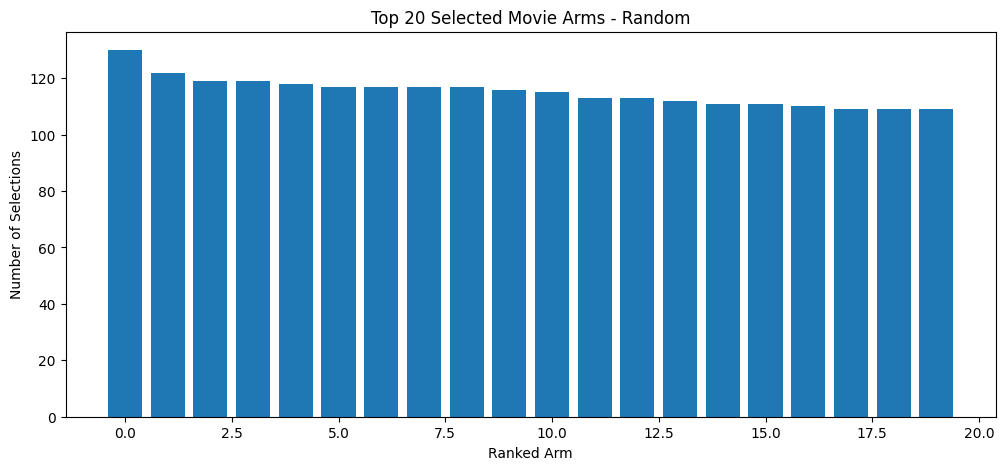

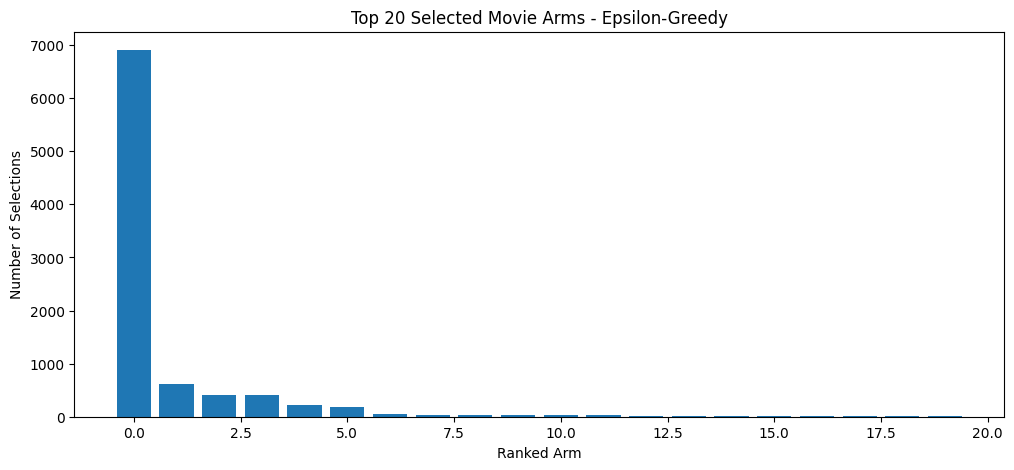

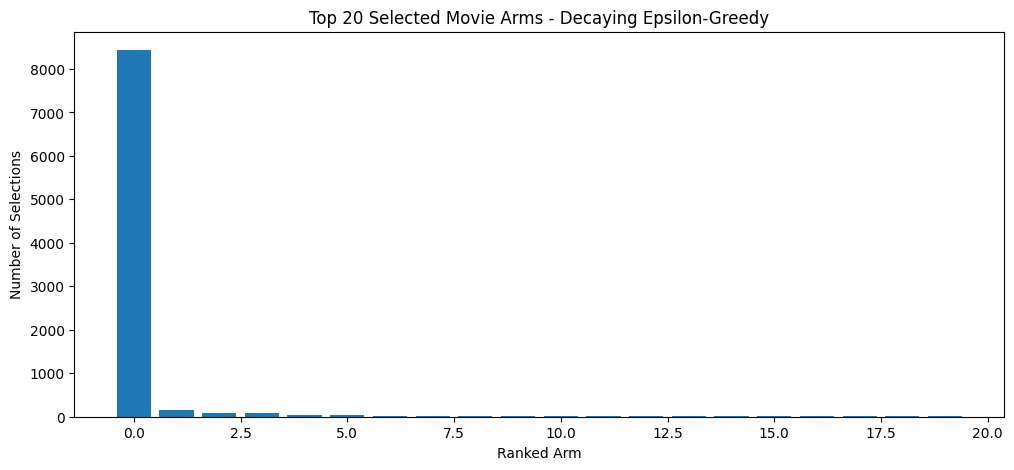

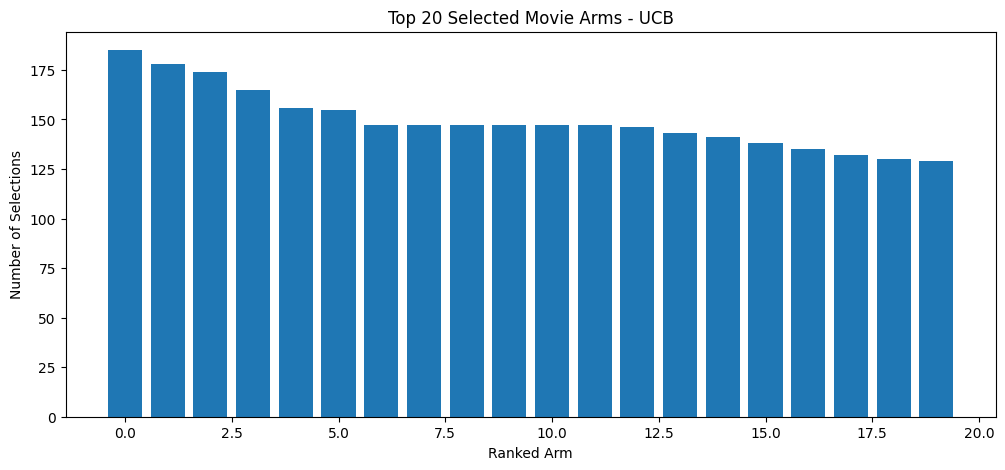

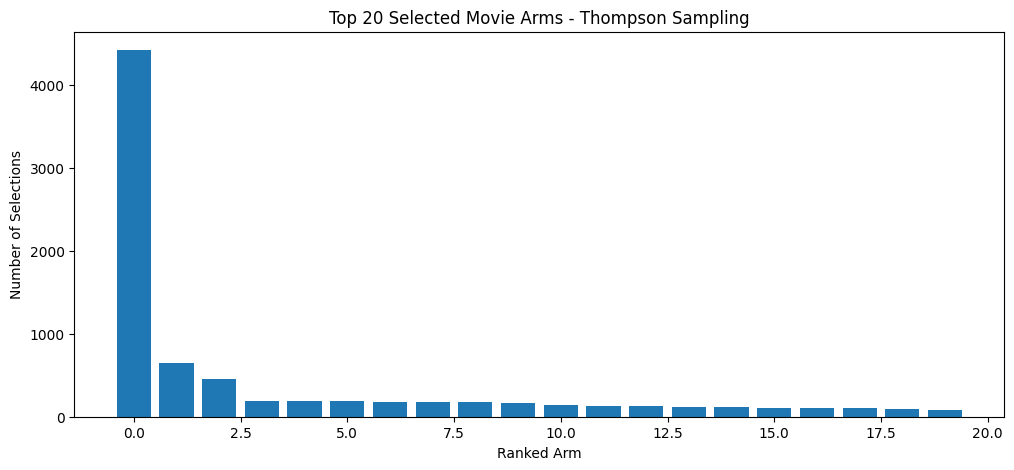

In [49]:
for name, counts in selection_counts.items():

    top_arms = np.argsort(
        counts
    )[::-1][:20]

    plt.figure(figsize=(12, 5))

    plt.bar(
        range(20),
        counts[top_arms]
    )

    plt.xlabel("Ranked Arm")
    plt.ylabel("Number of Selections")

    plt.title(
        f"Top 20 Selected Movie Arms - {name}"
    )

    plt.show()

# Create Final Comparison Table

In [50]:
final_comparison = []

for name, (
    rewards,
    arms
) in results.items():

    counts = np.bincount(
        arms,
        minlength=N_ARMS
    )

    most_selected_arm = (
        np.argmax(counts)
    )

    most_selected_movie = (
        arm_movies.iloc[
            most_selected_arm
        ]["title"]
    )

    final_comparison.append({

        "Algorithm": name,

        "Total Reward":
            rewards.sum(),

        "Average Reward":
            rewards.mean(),

        "Final Cumulative Regret":
            regret_results[name][-1],

        "Most Selected Arm":
            most_selected_arm,

        "Most Selected Movie":
            most_selected_movie,

        "Selections of Top Arm":
            counts[
                most_selected_arm
            ]
    })


final_comparison_df = pd.DataFrame(
    final_comparison
)

final_comparison_df

,Algorithm,Total Reward,Average Reward,Final Cumulative Regret,Most Selected Arm,Most Selected Movie,Selections of Top Arm
0,Random,7326,0.7326,1845.832220,14,Braveheart (1995),130
1,Epsilon-Greedy,8795,0.8795,353.059881,23,"Shawshank Redemption, The (1994)",6904
2,Decaying Epsilon-Greedy,8796,0.8796,382.190824,38,"Usual Suspects, The (1995)",8435
3,UCB,7627,0.7627,1527.646263,38,"Usual Suspects, The (1995)",185
4,Thompson Sampling,8644,0.8644,552.089274,23,"Shawshank Redemption, The (1994)",4424


# Sort by Average Reward

In [51]:
final_comparison_df.sort_values(
    "Average Reward",
    ascending=False
).reset_index(drop=True)

,Algorithm,Total Reward,Average Reward,Final Cumulative Regret,Most Selected Arm,Most Selected Movie,Selections of Top Arm
0,Decaying Epsilon-Greedy,8796,0.8796,382.190824,38,"Usual Suspects, The (1995)",8435
1,Epsilon-Greedy,8795,0.8795,353.059881,23,"Shawshank Redemption, The (1994)",6904
2,Thompson Sampling,8644,0.8644,552.089274,23,"Shawshank Redemption, The (1994)",4424
3,UCB,7627,0.7627,1527.646263,38,"Usual Suspects, The (1995)",185
4,Random,7326,0.7326,1845.832220,14,Braveheart (1995),130


# Identify What Each Algorithm Learned

In [52]:
print(
    "True optimal arm:",
    environment.best_arm
)

print(
    "True optimal movie:",
    arm_movies.iloc[
        environment.best_arm
    ]["title"]
)

print(
    "True optimal probability:",
    environment.best_probability
)

print("\n")

for name, (
    rewards,
    arms
) in results.items():

    counts = np.bincount(
        arms,
        minlength=N_ARMS
    )

    learned_arm = np.argmax(counts)

    print(
        f"{name:25s} -> "
        f"Arm {learned_arm:3d} -> "
        f"{arm_movies.iloc[learned_arm]['title']}"
    )

True optimal arm: 23
True optimal movie: Shawshank Redemption, The (1994)
True optimal probability: 0.918724741805119


Random                    -> Arm  14 -> Braveheart (1995)
Epsilon-Greedy            -> Arm  23 -> Shawshank Redemption, The (1994)
Decaying Epsilon-Greedy   -> Arm  38 -> Usual Suspects, The (1995)
UCB                       -> Arm  38 -> Usual Suspects, The (1995)
Thompson Sampling         -> Arm  23 -> Shawshank Redemption, The (1994)


# Learning Curves

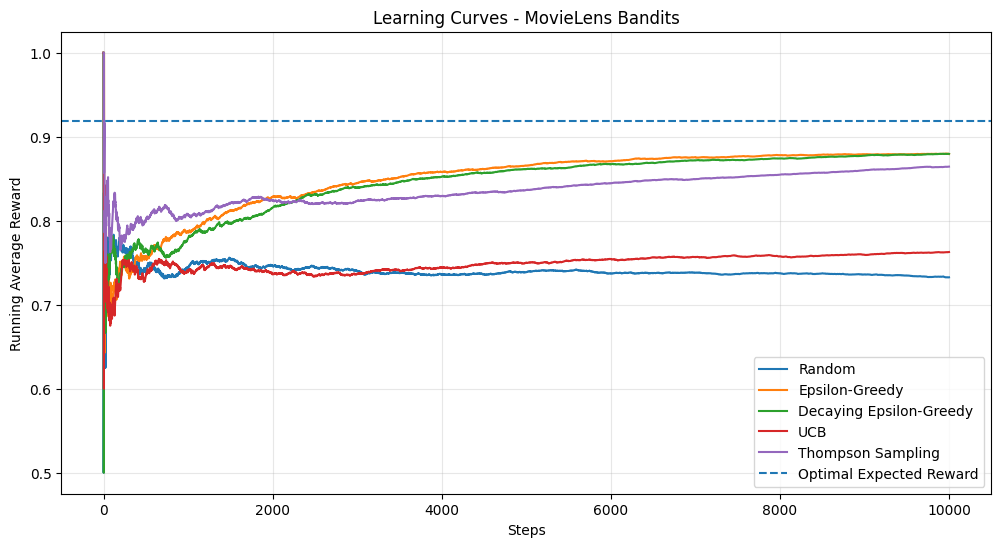

In [53]:
plt.figure(figsize=(12, 6))

for name, (
    rewards,
    arms
) in results.items():

    running_average = (
        np.cumsum(rewards)
        /
        np.arange(
            1,
            len(rewards) + 1
        )
    )

    plt.plot(
        running_average,
        label=name
    )

plt.axhline(
    environment.best_probability,
    linestyle="--",
    label="Optimal Expected Reward"
)

plt.xlabel("Steps")
plt.ylabel("Running Average Reward")

plt.title(
    "Learning Curves - MovieLens Bandits"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Test Different Epsilon Values

In [54]:
epsilon_values = [
    0.01,
    0.05,
    0.10,
    0.20,
    0.30
]

epsilon_experiments = {}

for epsilon in epsilon_values:

    bandit = EpsilonGreedy(
        n_arms=N_ARMS,
        epsilon=epsilon
    )

    rewards, arms = run_experiment(
        bandit,
        environment,
        N_STEPS
    )

    epsilon_experiments[
        epsilon
    ] = rewards

# Compare Epsilon Values

In [55]:
epsilon_summary = []

for epsilon, rewards in (
    epsilon_experiments.items()
):

    epsilon_summary.append({

        "Epsilon": epsilon,

        "Total Reward":
            rewards.sum(),

        "Average Reward":
            rewards.mean()
    })


epsilon_df = pd.DataFrame(
    epsilon_summary
)

epsilon_df

,Epsilon,Total Reward,Average Reward
0,0.01,8968,0.8968
1,0.05,8880,0.8880
2,0.10,8671,0.8671
3,0.20,8641,0.8641
4,0.30,8363,0.8363


# Plot Epsilon Comparison

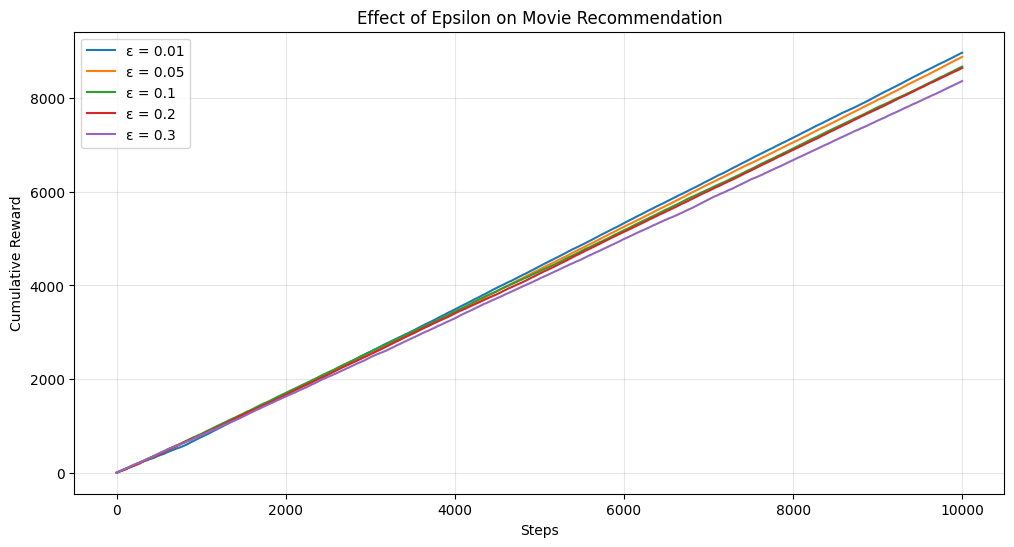

In [56]:
plt.figure(figsize=(12, 6))

for epsilon, rewards in (
    epsilon_experiments.items()
):

    plt.plot(
        np.cumsum(rewards),
        label=f"ε = {epsilon}"
    )

plt.xlabel("Steps")
plt.ylabel("Cumulative Reward")

plt.title(
    "Effect of Epsilon on Movie Recommendation"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Multiple Runs

In [57]:
N_RUNS = 20

print(
    f"Running {N_RUNS} experiments..."
)

Running 20 experiments...


# Multiple Run Evaluation Function

In [58]:
def evaluate_algorithm(
    algorithm_class,
    algorithm_kwargs,
    probabilities,
    n_steps,
    n_runs
):

    all_rewards = []

    for run in range(n_runs):

        environment = MovieBanditEnvironment(
            probabilities
        )

        bandit = algorithm_class(
            n_arms=len(probabilities),
            **algorithm_kwargs
        )

        rewards, arms = run_experiment(
            bandit,
            environment,
            n_steps
        )

        all_rewards.append(
            rewards
        )

    return np.array(
        all_rewards
    )

# Evaluate All Algorithms

In [59]:
evaluation_results = {}

evaluation_results[
    "Random"
] = evaluate_algorithm(
    RandomBandit,
    {},
    true_probabilities,
    N_STEPS,
    N_RUNS
)

evaluation_results[
    "Epsilon-Greedy"
] = evaluate_algorithm(
    EpsilonGreedy,
    {
        "epsilon": 0.1
    },
    true_probabilities,
    N_STEPS,
    N_RUNS
)

evaluation_results[
    "Decaying Epsilon-Greedy"
] = evaluate_algorithm(
    DecayingEpsilonGreedy,
    {
        "initial_epsilon": 1.0,
        "min_epsilon": 0.01,
        "decay": 0.999
    },
    true_probabilities,
    N_STEPS,
    N_RUNS
)

evaluation_results[
    "UCB"
] = evaluate_algorithm(
    UCB,
    {
        "c": 2.0
    },
    true_probabilities,
    N_STEPS,
    N_RUNS
)

evaluation_results[
    "Thompson Sampling"
] = evaluate_algorithm(
    ThompsonSampling,
    {},
    true_probabilities,
    N_STEPS,
    N_RUNS
)

print("Evaluation completed.")

Evaluation completed.


# Mean Reward Across Runs

In [60]:
mean_reward_results = {}

for name, rewards in (
    evaluation_results.items()
):

    mean_reward_results[name] = (
        rewards.mean()
    )

mean_reward_df = pd.DataFrame({
    "Algorithm":
        list(
            mean_reward_results.keys()
        ),

    "Mean Reward":
        list(
            mean_reward_results.values()
        )
})

mean_reward_df.sort_values(
    "Mean Reward",
    ascending=False
).reset_index(drop=True)

,Algorithm,Mean Reward
0,Decaying Epsilon-Greedy,0.882515
1,Epsilon-Greedy,0.876215
2,Thompson Sampling,0.860845
3,UCB,0.769470
4,Random,0.733555


# Mean Cumulative Reward

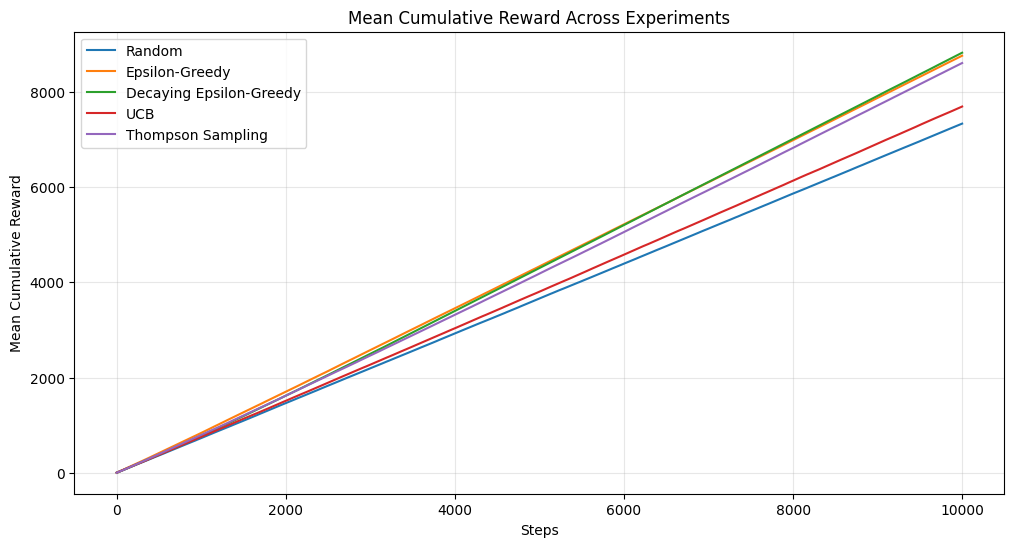

In [61]:
plt.figure(figsize=(12, 6))

for name, rewards in (
    evaluation_results.items()
):

    mean_rewards = rewards.mean(
        axis=0
    )

    mean_cumulative = np.cumsum(
        mean_rewards
    )

    plt.plot(
        mean_cumulative,
        label=name
    )

plt.xlabel("Steps")
plt.ylabel(
    "Mean Cumulative Reward"
)

plt.title(
    "Mean Cumulative Reward Across Experiments"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Mean Regret Across Runs

In [62]:
mean_regret_results = {}

for name, rewards in (
    evaluation_results.items()
):

    # Expected regret based on
    # the arm probabilities.
    #
    # We need to rerun the algorithms
    # to preserve their selected arms.

    pass

# Multiple Run Evaluation With Regret

In [63]:
def evaluate_algorithm_with_regret(
    algorithm_class,
    algorithm_kwargs,
    probabilities,
    n_steps,
    n_runs
):

    all_rewards = []
    all_regrets = []

    for run in range(n_runs):

        environment = MovieBanditEnvironment(
            probabilities
        )

        bandit = algorithm_class(
            n_arms=len(probabilities),
            **algorithm_kwargs
        )

        rewards = []
        regrets = []

        for step in range(n_steps):

            arm = bandit.select_arm()

            reward = environment.pull(
                arm
            )

            bandit.update(
                arm,
                reward
            )

            rewards.append(
                reward
            )

            regret = (
                environment.best_probability
                -
                probabilities[arm]
            )

            regrets.append(
                regret
            )

        all_rewards.append(
            rewards
        )

        all_regrets.append(
            regrets
        )

    return (
        np.array(all_rewards),
        np.array(all_regrets)
    )

# Run Multiple Experiments With Regret

In [64]:
full_evaluation = {}

algorithms = {

    "Random": (
        RandomBandit,
        {}
    ),

    "Epsilon-Greedy": (
        EpsilonGreedy,
        {
            "epsilon": 0.1
        }
    ),

    "Decaying Epsilon-Greedy": (
        DecayingEpsilonGreedy,
        {
            "initial_epsilon": 1.0,
            "min_epsilon": 0.01,
            "decay": 0.999
        }
    ),

    "UCB": (
        UCB,
        {
            "c": 2.0
        }
    ),

    "Thompson Sampling": (
        ThompsonSampling,
        {}
    )
}


for name, (
    algorithm_class,
    kwargs
) in algorithms.items():

    rewards, regrets = (
        evaluate_algorithm_with_regret(
            algorithm_class,
            kwargs,
            true_probabilities,
            N_STEPS,
            N_RUNS
        )
    )

    full_evaluation[name] = {
        "rewards": rewards,
        "regrets": regrets
    }

print("All experiments completed.")

All experiments completed.


# Mean Cumulative Reward Across Runs

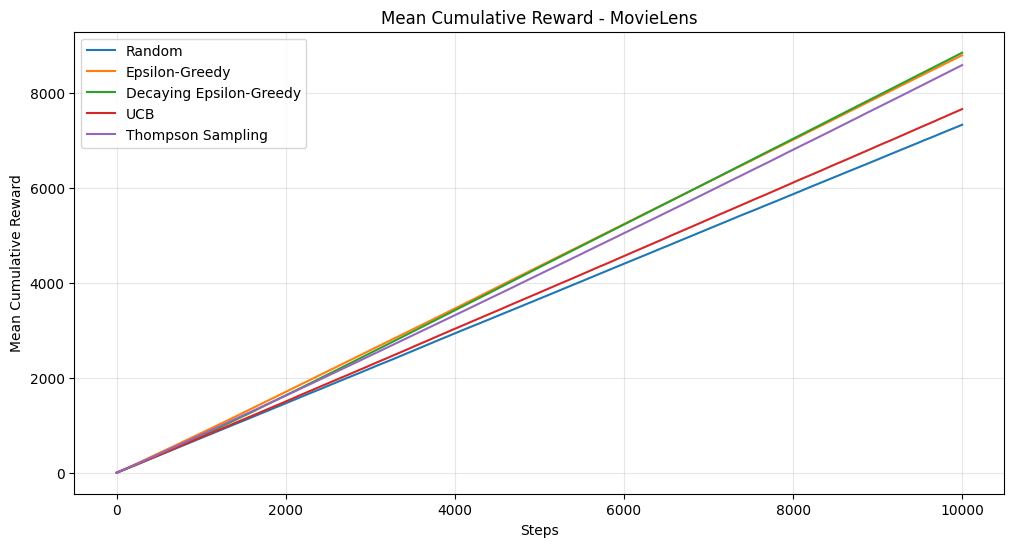

In [65]:
plt.figure(figsize=(12, 6))

for name, result in (
    full_evaluation.items()
):

    rewards = result["rewards"]

    mean_rewards = rewards.mean(
        axis=0
    )

    mean_cumulative_reward = (
        np.cumsum(
            mean_rewards
        )
    )

    plt.plot(
        mean_cumulative_reward,
        label=name
    )

plt.xlabel("Steps")
plt.ylabel(
    "Mean Cumulative Reward"
)

plt.title(
    "Mean Cumulative Reward - MovieLens"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Mean Cumulative Regret

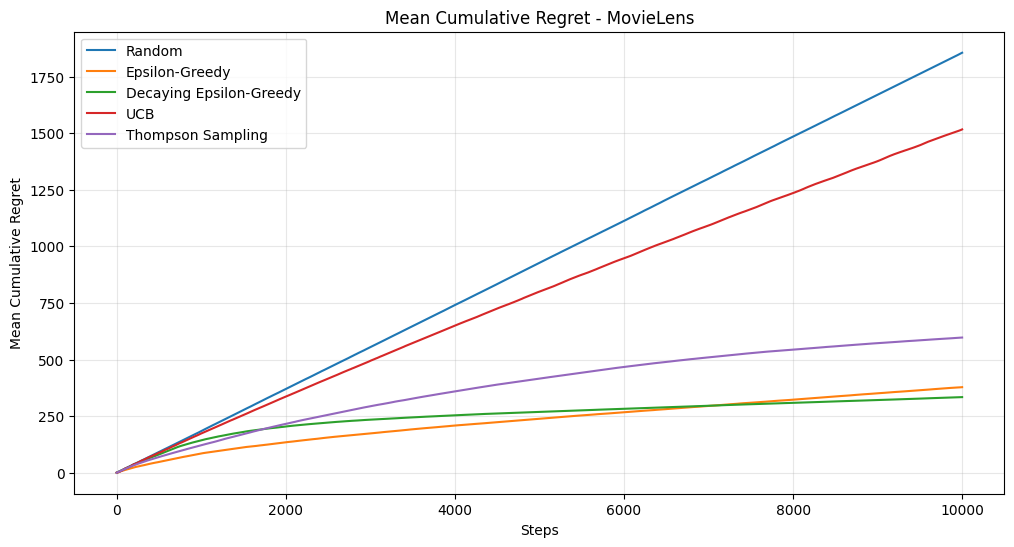

In [66]:
plt.figure(figsize=(12, 6))

for name, result in (
    full_evaluation.items()
):

    regrets = result["regrets"]

    mean_regrets = regrets.mean(
        axis=0
    )

    mean_cumulative_regret = (
        np.cumsum(
            mean_regrets
        )
    )

    plt.plot(
        mean_cumulative_regret,
        label=name
    )

plt.xlabel("Steps")
plt.ylabel(
    "Mean Cumulative Regret"
)

plt.title(
    "Mean Cumulative Regret - MovieLens"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Final Experimental Summary

In [67]:
summary = []

for name, result in (
    full_evaluation.items()
):

    rewards = result["rewards"]

    regrets = result["regrets"]

    total_rewards = (
        rewards.sum(axis=1)
    )

    total_regrets = (
        regrets.sum(axis=1)
    )

    summary.append({

        "Algorithm": name,

        "Mean Total Reward":
            total_rewards.mean(),

        "Std Total Reward":
            total_rewards.std(),

        "Mean Average Reward":
            rewards.mean(),

        "Mean Final Cumulative Regret":
            total_regrets.mean(),

        "Std Final Regret":
            total_regrets.std()
    })


summary_df = pd.DataFrame(
    summary
)

summary_df.sort_values(
    "Mean Total Reward",
    ascending=False
).reset_index(drop=True)

,Algorithm,Mean Total Reward,Std Total Reward,Mean Average Reward,Mean Final Cumulative Regret,Std Final Regret
0,Decaying Epsilon-Greedy,8856.35,99.958629,0.885635,334.030159,86.495526
1,Epsilon-Greedy,8803.65,90.759724,0.880365,377.960513,82.692667
2,Thompson Sampling,8595.20,47.883818,0.859520,597.190185,54.508469
3,UCB,7667.70,38.692506,0.766770,1516.557483,11.902656
4,Random,7337.95,47.977573,0.733795,1855.278341,10.070406


# Best Performing Algorithm

In [68]:
best_algorithm = (
    summary_df
    .sort_values(
        "Mean Total Reward",
        ascending=False
    )
    .iloc[0]
)

print(
    "Best algorithm based on mean total reward:"
)

print(
    best_algorithm["Algorithm"]
)

print(
    "\nMean total reward:",
    best_algorithm["Mean Total Reward"]
)

print(
    "Mean average reward:",
    best_algorithm["Mean Average Reward"]
)

print(
    "Mean cumulative regret:",
    best_algorithm[
        "Mean Final Cumulative Regret"
    ]
)

Best algorithm based on mean total reward:
Decaying Epsilon-Greedy

Mean total reward: 8856.35
Mean average reward: 0.885635
Mean cumulative regret: 334.0301589216481


# Top Movies According to Historical Data

In [69]:
final_movie_table = (
    arm_movies[
        [
            "movie_id",
            "title",
            "genres",
            "total_ratings",
            "average_rating",
            "positive_rate"
        ]
    ]
    .sort_values(
        "positive_rate",
        ascending=False
    )
)

final_movie_table.head(20)

,movie_id,title,genres,total_ratings,average_rating,positive_rate
23,318,"Shawshank Redemption, The (1994)",Drama,2227,4.554558,0.918725
38,50,"Usual Suspects, The (1995)",Crime|Thriller,1783,4.517106,0.901851
11,1198,Raiders of the Lost Ark (1981),Action|Adventure,2514,4.477725,0.898966
17,527,Schindler's List (1993),Drama|War,2304,4.510417,0.898872
24,858,"Godfather, The (1972)",Action|Crime|Drama,2223,4.524966,0.894737
90,750,Dr. Strangelove or: How I Learned to Stop Worr...,Sci-Fi|War,1367,4.449890,0.882955
43,1193,One Flew Over the Cuckoo's Nest (1975),Drama,1725,4.390725,0.880580
13,2762,"Sixth Sense, The (1999)",Thriller,2459,4.406263,0.879626
1,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,2991,4.453694,0.876630
9,593,"Silence of the Lambs, The (1991)",Drama|Thriller,2578,4.351823,0.873545


# Save Processed Dataset

In [70]:
processed_path = (
    "/content/movielens_processed.csv"
)

ratings.to_csv(
    processed_path,
    index=False
)

print(
    "Saved processed dataset to:"
)

print(processed_path)

Saved processed dataset to:
/content/movielens_processed.csv


# Final Visualization

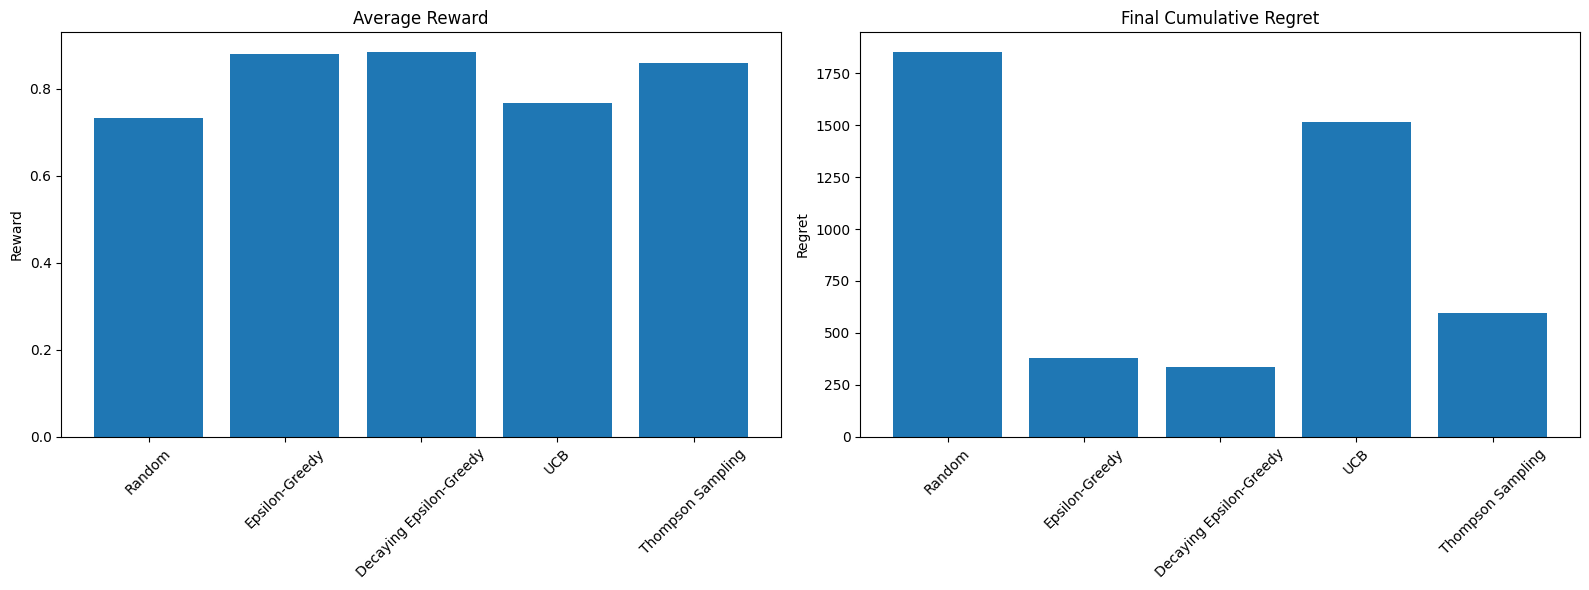

In [72]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

# -------------------------------
# Average Reward
# -------------------------------

algorithms_names = (
    list(full_evaluation.keys())
)

average_rewards = []

for name in algorithms_names:

    rewards = (
        full_evaluation[name]["rewards"]
    )

    average_rewards.append(
        rewards.mean()
    )

axes[0].bar(
    algorithms_names,
    average_rewards
)

axes[0].set_title(
    "Average Reward"
)

axes[0].set_ylabel(
    "Reward"
)

axes[0].tick_params(
    axis="x",
    rotation=45
)


# -------------------------------
# Final Cumulative Regret
# -------------------------------

final_regrets = []

for name in algorithms_names:

    regrets = (
        full_evaluation[name]["regrets"]
    )

    final_regrets.append(
        regrets.sum(axis=1).mean()
    )

axes[1].bar(
    algorithms_names,
    final_regrets
)

axes[1].set_title(
    "Final Cumulative Regret"
)

axes[1].set_ylabel(
    "Regret"
)

axes[1].tick_params(
    axis="x",
    rotation=45
)

plt.tight_layout()

plt.show()

# Final Conclusions

## Dataset

The MovieLens 1M dataset was used to create a simulated movie
recommendation environment.

The historical ratings were converted into binary rewards:

    Rating >= 4 → Reward 1
    Rating < 4  → Reward 0

Each movie was treated as an arm.

## Algorithms

The following algorithms were implemented:

1. Random Baseline
2. Epsilon-Greedy
3. Decaying Epsilon-Greedy
4. Upper Confidence Bound (UCB)
5. Thompson Sampling

## Evaluation

The algorithms were evaluated using:

- Total Reward
- Average Reward
- Cumulative Reward
- Cumulative Regret
- Movie Selection Frequency
- Multiple Independent Runs

## Important observation

The algorithms should gradually identify movies with higher historical
positive-rating probabilities.

However, performance differences depend on:

- Number of arms
- Number of iterations
- Epsilon
- Epsilon decay
- UCB exploration coefficient
- Reward definition
- Random seed
- Number of experimental runs

## Important limitation

This is an offline simulation.

MovieLens contains historical user-item interactions rather than a
live environment where the bandit can actually recommend a movie and
receive new user feedback.

Therefore, the historical positive-rating probabilities are used to
construct a simulated reward environment.

For a production recommendation system, a contextual bandit would be
more appropriate because the reward should depend on user context.

A more advanced version could use:

    User
      ↓
    User Features
      ↓
    Contextual Bandit
      ↓
    Movie Recommendation
      ↓
    User Interaction
      ↓
    Reward
      ↓
    Model Update

Possible contextual bandit algorithms include:

- LinUCB
- Contextual Thompson Sampling
- Neural Contextual Bandits
- Logistic Bandits

## Final Learning Pipeline

    MovieLens 1M
          ↓
    Data Preprocessing
          ↓
    Rating → Reward
          ↓
    Movie → Arm
          ↓
    Bandit Environment
          ↓
    Epsilon-Greedy
          ↓
    Decaying Epsilon-Greedy
          ↓
    UCB
          ↓
    Thompson Sampling
          ↓
    Reward / Regret Analysis
          ↓
    Algorithm Comparison